### **DeepDream**

DeepDream is an artistic image-modification technique that uses the representations learned by convolutional neural networks. The DeepDream algorithm consisting of running a convnet in reverse: doing gradient ascent on the input.



*   Try to maximize the activation of enitre layers rather than that of a specific filter, thus mixing together visualizations of large numbers of features at once.
*   Start not from blank, slightly noisy input, but rather from an existing image - thus the resulting effects latch on to preexisting visual patterns, distorting elements of the image in a somewhat artistic fashion.
*   The input images are processed at different scales (called octaves), which improves the quality of visualizations.

### Implementing DeepDream

We'll start from a convnet pretrained on ImageNet. Our Convnet of choice will naturally affect our visualizations, because different convnet architectures result in different learned features. We'll use Inception as per the the original paper (https://www3.cs.stonybrook.edu/~cse352/T12talk.pdf)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.applications import inception_v3

model = inception_v3.InceptionV3(weights='imagenet', include_top=False) # Builds the Inception V3 network, without its convolutional base.

model.trainable = False # We won’t be training the model, so this command disables all training-specific operations.

2026-06-30 14:14:00.700783: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-30 14:14:00.700802: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-06-30 14:14:02.450639: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-30 14:14:02.450711: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-06-30 14:14:02.450761: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: lib

Now, we will compute the loss. We will maximize a weighted sum of the L2 norm of the activations of a set high-level layers (The layers we will choose where we can recognize some classes). 

In [2]:
### Defining the loss to be maximized
layer_contributions = {
    'mixed2': 0.2,
    'mixed3': 3.0,
    'mixed4': 2.0,
    'mixed5': 1.5,
}

# Creates a dictionary that mapslayer names to layer instances
layer_names = list(layer_contributions.keys())
layer_outputs = [model.get_layer(name).output for name in layer_names]
feature_extractor = tf.keras.Model(inputs=model.input, outputs=layer_outputs)


def compute_loss_and_grads(x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        activations = feature_extractor(x, training=False) # Retrieves the layer’s output 
        loss = tf.constant(0.0, dtype=tf.float32) # define the loss by adding layer contributions to this scalar variable
        for layer_name, activation in zip(layer_names, activations):
            coeff = tf.constant(layer_contributions[layer_name], dtype=tf.float32)
            scaling = tf.cast(tf.size(activation), tf.float32)
            loss += coeff * tf.reduce_sum(tf.square(activation[:, 2:-2, 2:-2, :])) / scaling # Adds the L2 norm of the features of a layer to the loss. 
            # We avoid border artifacts by only involving nonborder pixels in the loss.

    grads = tape.gradient(loss, x) # Computes the gradients of the dream with regard to the loss
    grads /= tf.maximum(tf.reduce_mean(tf.abs(grads)), 1e-7) # Normalizes the gradients (important trick)
    return loss, grads

In [3]:
### Gradient ascent process
dream = tf.Variable(np.random.uniform(size=(1, 299, 299, 3)).astype('float32'))


def gradient_ascent(x, iterations, step, max_loss=None):
    x = tf.Variable(x, dtype=tf.float32)
    for i in range(iterations):
        loss_value, grad_values = compute_loss_and_grads(x)
        if max_loss is not None and loss_value > max_loss:
            break
        print('...Loss value at', i, ':', loss_value.numpy())
        x.assign_add(step * grad_values)
    return x

Finally: the actual DeepDream algorithm. First, we define a list of scales (`octaves`) at which to process the images. Each successive scale is larger than the previous one by a factor of 1.4 (its 40% larger): we start by processing a small image and then increasingly scale it up.

To avoid losing a lot of image detail after each successive scale-up (resulting in increasingly blurry or pixelated images), we can use a simple trick: after each scale-
up, you’ll reinject the lost details back into the image, which is possible because you know what the original image should look like at the larger scale. 

In [4]:
### Running gradient ascent over different successive scales (octaves)

import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.applications import inception_v3

step = 0.01  # Gradient ascent step size
num_octaves = 3  # Number of scales at which to run gradient ascent
octave_scale = 1.4  # Size ratio between scales
iterations = 20  # Number of ascent steps per scale
max_loss = 10.0  # Optional maximum loss threshold

base_image_path = tf.keras.utils.get_file('cat.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')

img = tf.keras.preprocessing.image.load_img(base_image_path, target_size=(299, 299))
img = np.array(img).astype('float32')
img = np.expand_dims(img, axis=0)

# Preprocess the image for InceptionV3 (scales pixels to [-1, 1])
img = inception_v3.preprocess_input(img)


def save_img(img, fname):
    # Accept either a tf.Tensor or numpy array and convert to uint8 image in [0,255]
    if isinstance(img, tf.Tensor):
        arr = img.numpy()
    else:
        arr = np.array(img)
    arr = arr[0]
    # If values are in [-1, 1], convert back to [0, 255]
    if arr.min() < 0.0 or arr.max() <= 1.0:
        arr = (arr + 1.0) * 127.5
    arr = np.clip(arr, 0, 255).astype('uint8')
    Image.fromarray(arr).save(fname)

# Prepares a list of shape tuples defining the different scales at which to run gradient ascent
original_shape = img.shape[1:3]
successive_shapes = [original_shape]
for i in range(1, num_octaves):
    shape = tuple([int(dim / (octave_scale ** i)) for dim in original_shape])
    successive_shapes.append(shape)
successive_shapes = successive_shapes[::-1]  # Reverse the list of shapes

original_img = np.copy(img)  # Saves the original image (preprocessed)
shrunken_original_img = tf.image.resize(original_img, successive_shapes[0])  # Shrinks the original image to the smallest scale

for shape in successive_shapes:
    print('Processing image shape', shape)
    img = tf.image.resize(img, shape)  # Resizes the image to the current scale
    img = gradient_ascent(img, iterations=iterations, step=step, max_loss=max_loss)  # Runs gradient ascent

    # Upscales the smaller version of the original image: it will be subtracted from the upscaled image
    upscaled_shrunken_original_img = tf.image.resize(shrunken_original_img, shape)
    # Computes the high-frequency part of the current image
    same_size_original = tf.image.resize(original_img, shape)
    lost_detail = same_size_original - upscaled_shrunken_original_img

    img = img + lost_detail  # Adds back the high-frequency part to the current image
    shrunken_original_img = tf.image.resize(original_img, shape)  # Updates the shrunken version of the original image
    save_img(img, fname='dream_at_scale_' + str(shape) + '.png')  # Saves the current generated image

save_img(img, fname='final_dream.png')  # Saves the final generated image

Processing image shape (152, 152)
...Loss value at 0 : 0.7581583
...Loss value at 1 : 1.0059106
...Loss value at 2 : 1.3856125
...Loss value at 3 : 1.7356324
...Loss value at 4 : 2.1297777
...Loss value at 5 : 2.5077634
...Loss value at 6 : 2.767365
...Loss value at 7 : 3.2317185
...Loss value at 8 : 3.6285079
...Loss value at 9 : 3.9087996
...Loss value at 10 : 4.173494
...Loss value at 11 : 4.475788
...Loss value at 12 : 4.773538
...Loss value at 13 : 5.101549
...Loss value at 14 : 5.3536725
...Loss value at 15 : 5.623845
...Loss value at 16 : 5.806068
...Loss value at 17 : 6.133997
...Loss value at 18 : 6.385437
...Loss value at 19 : 6.590051
Processing image shape (213, 213)
...Loss value at 0 : 2.0284586
...Loss value at 1 : 3.1139054
...Loss value at 2 : 4.0336304
...Loss value at 3 : 4.796249
...Loss value at 4 : 5.4284954
...Loss value at 5 : 6.0468245
...Loss value at 6 : 6.4763355
...Loss value at 7 : 6.987035
...Loss value at 8 : 7.417424
...Loss value at 9 : 7.856002
...Los

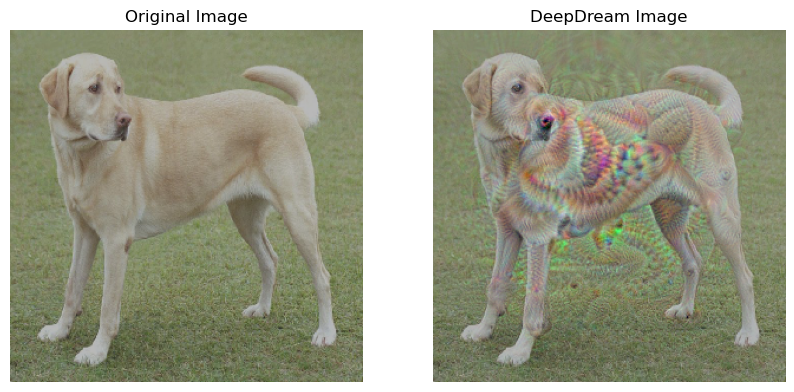

In [6]:
### Auxiliary functions for displaying images in the notebook
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def deprocess_image(x):
    # Convert tensors to numpy and operate on a copy
    if isinstance(x, (tf.Tensor, tf.Variable)):
        x = x.numpy()
    x = np.array(x).astype('float32').copy()

    # Normalize tensor: center on 0., ensure std is 0.1
    x -= x.mean()
    x /= (x.std() + 1e-5)
    x *= 0.1

    # Clip to [0, 1]
    x += 0.5
    x = np.clip(x, 0, 1)

    # Convert to RGB array
    x *= 255
    x = np.clip(x, 0, 255).astype('uint8')
    return x

# Displays the original and final dream images side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(deprocess_image(original_img[0]))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('DeepDream Image')
plt.imshow(deprocess_image(img[0]))
plt.axis('off')
plt.show()

#### **Wrapping up**

* DeepDream consists of running a convnet in reverse to generate inputs based on the representations learned by the network.
* The results produced are fun and somewhat similar to the visual artifacts induced in humans by the disruption of the visual cortex via psychedelics.